In [31]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [32]:
load_dotenv()

python-dotenv could not parse statement starting at line 5
python-dotenv could not parse statement starting at line 6


True

In [33]:
model = ChatOpenAI()

In [34]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [35]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

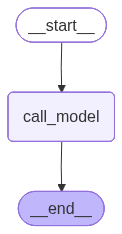

In [36]:
graph = builder.compile()
graph

In [37]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Dilip ."}]})

{'messages': [HumanMessage(content='Hi! My name is Dilip .', additional_kwargs={}, response_metadata={}, id='9455f136-238f-4feb-bece-d5499e9d3d7c'),
  AIMessage(content='Hello Dilip! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNHITNgQncKMBbG5jQgJY6EtQXlBG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d24e3-d7fc-7bf3-a48e-f431b56e9de2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 11, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_to

In [38]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='28b19556-1af0-4958-b759-450180dd4bdc'),
  AIMessage(content="I'm sorry, but I do not know your name as I am an AI assistant and don't have access to personal information. Feel free to introduce yourself to me!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 12, 'total_tokens': 46, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNHIWJ4LbWiQSAw0hkuEbU9tc1EK6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d24e3-de7a-7320-a53e-5d39a2b6af17-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'ou

In [39]:
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

In [40]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [41]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [42]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [43]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Dilip."}]}, config)

{'messages': [HumanMessage(content='Hi! My name is Dilip.', additional_kwargs={}, response_metadata={}, id='85260d9b-230b-4715-8726-f709296d644c'),
  AIMessage(content='Hello, Dilip! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 15, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNHIX34RuVZClCfHcfLpdz0FsrBWM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d24e3-e4a8-7641-a6b4-942af409966f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 12, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_to

In [44]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config2)

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='5b1f2229-58fb-46c8-88b4-80526e6f20da'),
  AIMessage(content="I'm sorry, I do not know your name as I am an AI digital assistant and do not have access to personal information.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 12, 'total_tokens': 38, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNHIYWNcQOxrGEV64gcdIZfRkTeaG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d24e3-e6a9-77a1-94ac-ae06b24bad11-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 26, 'total_tokens': 

In [45]:
snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Dilip.
- AIMessage : Hello, Dilip! How can I assist you today?
